## Read and Setup the Dataset

In [1]:
import pandas as pd
fp ="../data/coffee_prices.csv"
df = pd.read_csv(fp)

In [2]:
cols = ["date", "signal"]
df.columns = cols

In [3]:
df

,date,signal
0,1990-01-01,75.829987
1,1990-02-01,84.010010
2,1990-03-01,93.959991
3,1990-04-01,93.730011
4,1990-05-01,92.019989
...,...,...
421,2025-02-01,409.516500
422,2025-03-01,404.210476
423,2025-04-01,392.912727
424,2025-05-01,397.588636


## Run SSA
1. Define a window size
2. Run SSA
3. Analyze the eigen value spectrum

In [4]:
series = df.signal
series.index = df.date

In [5]:
from ssalib import SingularSpectrumAnalysis
wdw = 12
ssa = SingularSpectrumAnalysis(series, window=wdw)

In [6]:
ssa.decompose()

SingularSpectrumAnalysis(timeseries=<Series shape=(426,)>, window=12, svd_matrix='SSAMatrixType.BK_TRAJECTORY', svd_solver='numpy_standard', standardize=True)

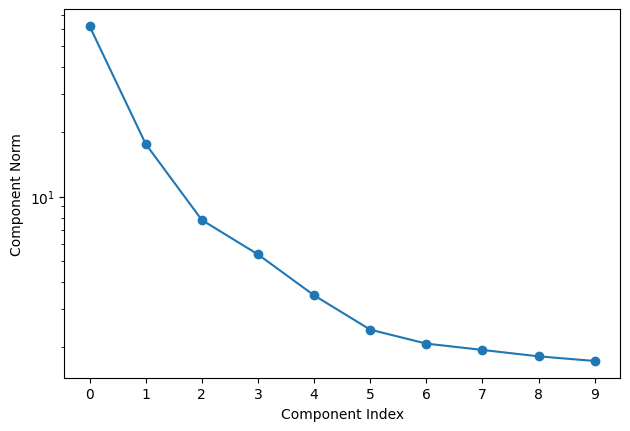

In [7]:
# Visualize results, in this case, singular values
fig, ax = ssa.plot(kind='values', marker='o')

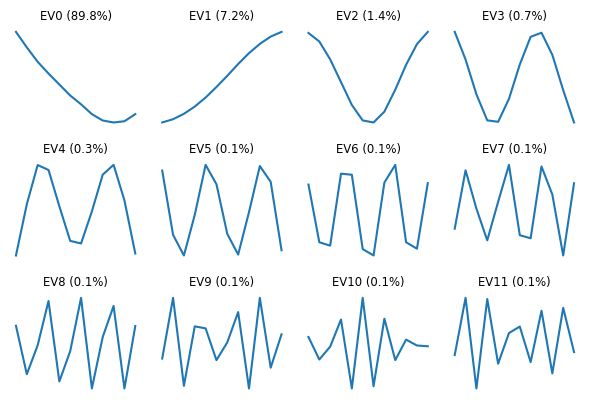

In [8]:
fig, axes = ssa.plot(kind='vectors')

## Apply Grouping

In [9]:
ssa.reconstruct(groups={'Trend': [0, 1,2,3], 'Seasonal': [], "residuals":[4,5,6,7,8,9,10,11]})

SingularSpectrumAnalysis(timeseries=<Series shape=(426,)>, window=12, svd_matrix='SSAMatrixType.BK_TRAJECTORY', svd_solver='numpy_standard', standardize=True)

## Residual Analysis

In [10]:
ssa["residuals"]

date
1990-01-01   -0.104687
1990-02-01   -0.048280
1990-03-01    0.060556
1990-04-01    0.046652
1990-05-01    0.019418
                ...   
2025-02-01    0.261014
2025-03-01   -0.001753
2025-04-01   -0.148643
2025-05-01    0.092929
2025-06-01   -0.117539
Name: residuals, Length: 426, dtype: float64

In [11]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

In [12]:

# 3. Perform the Durbin-Watson test
dw_statistic = durbin_watson(ssa["residuals"].values)

print(f"Durbin-Watson statistic: {dw_statistic}")

Durbin-Watson statistic: 2.4239171582042167


<Axes: ylabel='Density'>

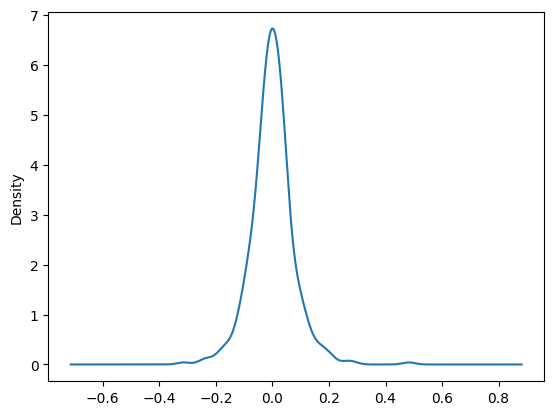

In [13]:
ssa["residuals"].plot.kde()

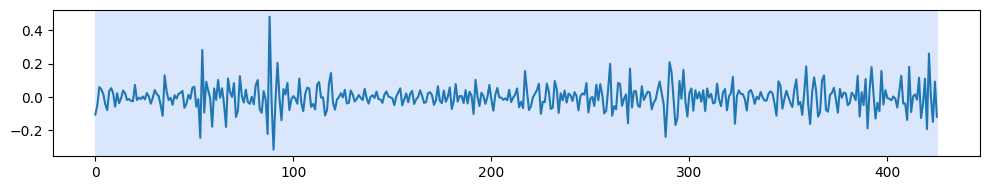

In [14]:
import ruptures as rpt
import matplotlib.pyplot as plt
from math import log
algo = rpt.Pelt(model="rbf").fit(ssa["residuals"].values)
rec_pen = 2*log(ssa["residuals"].shape[0],2)
# 3. Predict the change points
# The 'pen' parameter controls the sensitivity (higher penalty, fewer change points)
result = algo.predict(pen=10)

# 4. Display the results (optional, requires matplotlib)
rpt.display(ssa["residuals"].values, result)
plt.show()

1. The residuals do not explain a lot of variation in the signal
2. Change point detection on the residuals, run with the assumption that we don't know the the change points apriori, with a
penalty $\beta = 2 . \log(N)$ suggests there are no change points in the noise. The implication is that unexplained variance does not change over the observation period. The change points of interest are in the trend and seasonal component.

In [15]:
result

[426]

<Axes: xlabel='date'>

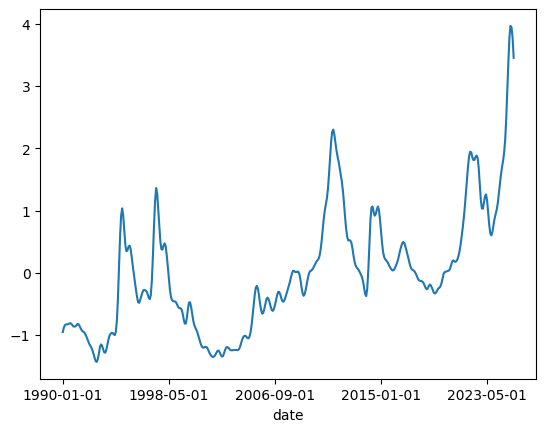

In [16]:
ssa["Trend"].plot()

<Axes: xlabel='date'>

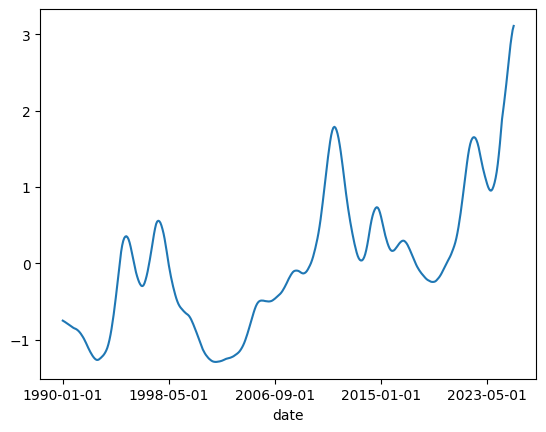

In [17]:
ssa[0].plot()

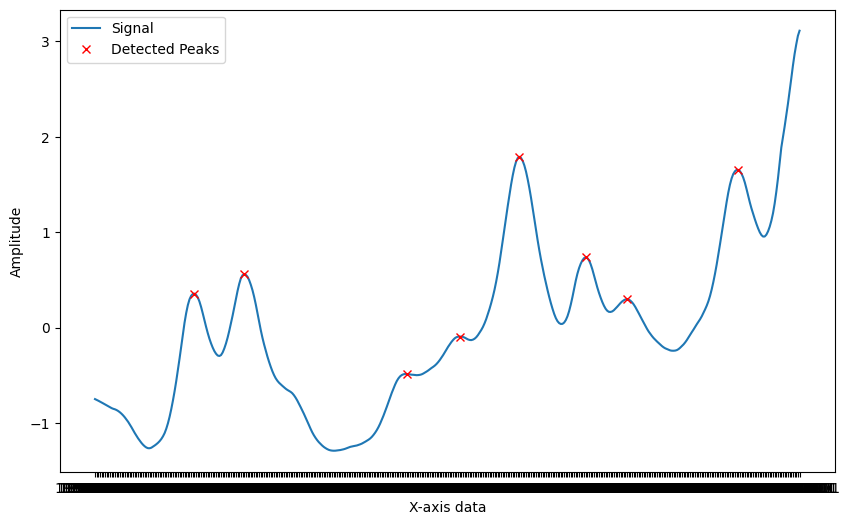

In [18]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
the_signal = ssa[0].values
x = series.index.values
peaks_indices, properties = find_peaks(the_signal)

# 3. Plot the results (optional, but helpful for visualization)
plt.figure(figsize=(10, 6))
plt.plot(x, the_signal, label='Signal')
plt.plot(x[peaks_indices], the_signal[peaks_indices], 'x', color='red', label='Detected Peaks')
plt.xlabel('X-axis data')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

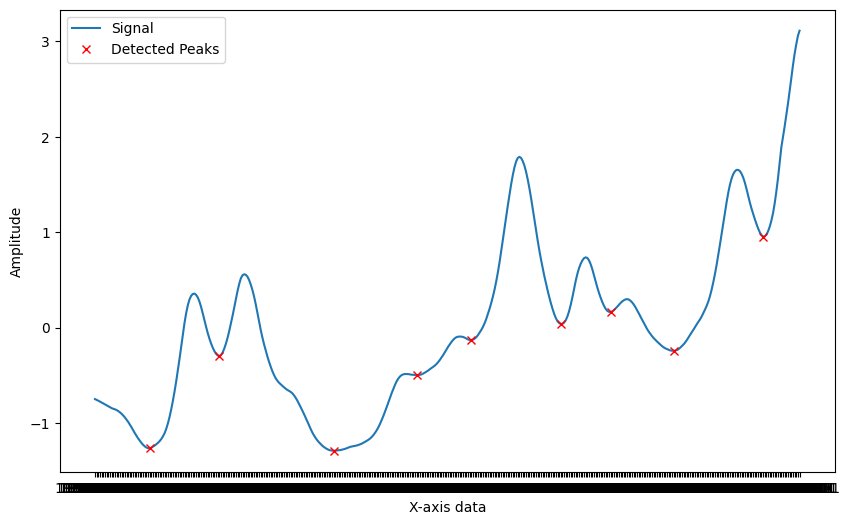

In [19]:

the_signal = -ssa[0].values
x = series.index.values
peaks_indices, properties = find_peaks(the_signal)
the_signal = ssa[0].values

# 3. Plot the results (optional, but helpful for visualization)
plt.figure(figsize=(10, 6))
plt.plot(x, the_signal, label='Signal')
plt.plot(x[peaks_indices], the_signal[peaks_indices], 'x', color='red', label='Detected Peaks')
plt.xlabel('X-axis data')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

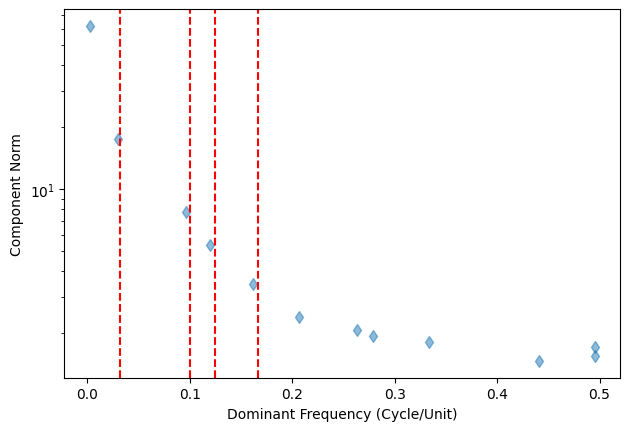

In [20]:
fig, ax = ssa.plot(
    n_components=12,
    rank_by='freq',
    marker='d', ls='none', alpha=.5
)
ax.axvline(x=(1/31), color='r', linestyle='--', label='Vertical line at x=1/31')
ax.axvline(x=(1/10), color='r', linestyle='--', label='Vertical line at x=1/10')
ax.axvline(x=(1/8), color='r', linestyle='--', label='Vertical line at x=1/8')
ax.axvline(x=(1/6), color='r', linestyle='--', label='Vertical line at x=1/6')

In [21]:
ssa.to_frame()

,ssa_original,ssa_preprocessed,ssa_reconstructed,ssa_residuals,Trend,Seasonal,residuals
date,,,,,,,
1990-01-01,75.829987,-1.056529,-1.056529,-1.554312e-15,-0.951842,0.0,-0.104687
1990-02-01,84.010010,-0.931430,-0.931430,-3.330669e-16,-0.883150,0.0,-0.048280
1990-03-01,93.959991,-0.779262,-0.779262,-2.331468e-15,-0.839817,0.0,0.060556
1990-04-01,93.730011,-0.782779,-0.782779,-8.881784e-16,-0.829431,0.0,0.046652
1990-05-01,92.019989,-0.808931,-0.808931,-7.771561e-16,-0.828349,0.0,0.019418
...,...,...,...,...,...,...,...
2025-02-01,409.516500,4.046639,4.046639,5.329071e-15,3.785625,0.0,0.261014
2025-03-01,404.210476,3.965493,3.965493,6.661338e-15,3.967246,0.0,-0.001753
2025-04-01,392.912727,3.792713,3.792713,7.105427e-15,3.941356,0.0,-0.148643


## Knowledge Base Logging

In [22]:
from kmds.ontology.kmds_ontology import *
from kmds.tagging.tag_types import ExploratoryTags
kaw = KnowledgeExtractionExperimentationWorkflow("coffee_prices_35_year_analysis", namespace=onto)

In [23]:
from kmds.ontology.intent_types import IntentType
exp_obs_list = []
observation_count :int = 1
e1 = ExploratoryObservation(namespace=onto)

In [24]:
from google import genai
from google.genai import types
import os
from dotenv import load_dotenv

load_dotenv()   

True

In [25]:
model_observations = " This dataset is the price of coffee in cents per lb starting 1991 and going through till October 2025. It can be\
downloaded from the FRED (https://fred.stlouisfed.org/) website. A review of the raw dataset may leave the analyst with a sense of hopelessness,\
however, as we will show, algorithmic techniques can be applied to summarize this dataset effectively"
model_observations += "1. Singular Spectrum Analysis was used to summarize the variation observed in coffee prices during this 35 year period 2.\
The variation can be explained by four sources of variation, one accounting for about 90 percent and the others contributing 7.2, 1.4 and 0.7 percent respectively"
model_observations += " The change points in this 35 year period can be identified by a peak finding algorithm that captures the end of trend cycles.\
SSA is based on SVD and therefore frequency components associated with the decomposition can also be identified. The reader is urged to refer to \
this notebook for the implementation details."
model_observations += " You will need some trial and error to find the noise term. The test for serial correlation can help here. The Duribin\
watson test can be used to check if the residuals have serial correlation. A test statistic in the range 1.5 to 2.5 indicates a lack of\
serial correlation and is generally considered acceptable to conclude that there is no major first order correlation within the residuals."


In [26]:

# Get AI response using the Gemini model
API_KEY = os.getenv("GEMINI_API_KEY")
client = genai.Client(api_key=API_KEY)
your_input = f"Can you summarize the following model observations succintly and return it as plain text string: {model_observations}"
response = client.models.generate_content(
model="gemini-2.5-flash",
contents=your_input,)

#response = model.generate_content(user_input)
ai_response = response.text

In [27]:
ai_response

'This analysis of coffee prices (1991-2025, from FRED) uses Singular Spectrum Analysis (SSA) to summarize variation. SSA explains price variation through four sources (90%, 7.2%, 1.4%, 0.7%) and identifies frequency components via SVD. Peak finding detects change points at the end of trend cycles. The Durbin-Watson test (1.5-2.5 acceptable range) can be used to identify the noise term by assessing residual serial correlation.'

In [28]:

e1.finding = ai_response
e1.finding_sequence = observation_count
e1.exploratory_observation_type = ExploratoryTags.DATA_QUALITY_OBSERVATION.value
e1.intent = IntentType.DATA_UNDERSTANDING.value
exp_obs_list.append(e1)

In [29]:
observation_count += 1
e2 = ExploratoryObservation(namespace=onto)
e2.finding = "Just like that, a 35 year history of coffee prices has been characterized and documented."
e2.finding_sequence = observation_count
e2.exploratory_observation_type = ExploratoryTags.DATA_QUALITY_OBSERVATION.value
e2.intent = IntentType.DATA_UNDERSTANDING.value
exp_obs_list.append(e2)
kaw.has_exploratory_observations = exp_obs_list

In [30]:
from owlready2 import *
from kmds.utils.path_utils import get_package_kb_path
KNOWLEDGE_BASE = "../data/kmds/coffee_prices_analysis.xml"
onto.save(file=KNOWLEDGE_BASE, format="rdfxml")